In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"

else:
    device = "cpu"

In [36]:
# generate new data
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0.0, scale=1.0, size=(2))
print(noise)

m = 0.1234
c = 0.6789
X = np.arange(0, 2, 0.04)
X = np.hstack((X, noise))

y = m * X + c

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# split = int(0.8 * len(X))
# X_train, y_train = X[:split], y[:split]
# X_test, y_test = X[split:], y[split:]

X_train_tensors = torch.from_numpy(X_train)
y_train_tensors = torch.from_numpy(y_train)
X_test_tensors = torch.from_numpy(X_test)
y_test_tensors = torch.from_numpy(y_test)

print(f"Shape of X_train is {X_train.shape} and type is {type(X_train)}")
print(
    f"Shape of X_train_tensors is {X_train_tensors.shape} and type is {type(X_train_tensors)}"
)

[ 0.30471708 -1.03998411]
Shape of X_train is (41,) and type is <class 'numpy.ndarray'>
Shape of X_train_tensors is torch.Size([41]) and type is <class 'torch.Tensor'>


In [37]:
def plot_data(
    X_train=X_train_tensors,
    y_train=y_train_tensors,
    X_test=X_test_tensors,
    y_test=y_test_tensors,
    predictions=None,
):
    plt.scatter(X_train, y_train, c="b", label="Training Data")
    plt.scatter(X_test, y_test, c="r", label="Testing data")

    if predictions is not None:
        plt.plot(X_test, predictions, c="g", label="Predictions")

    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("X vs y")
    plt.legend()
    plt.show()

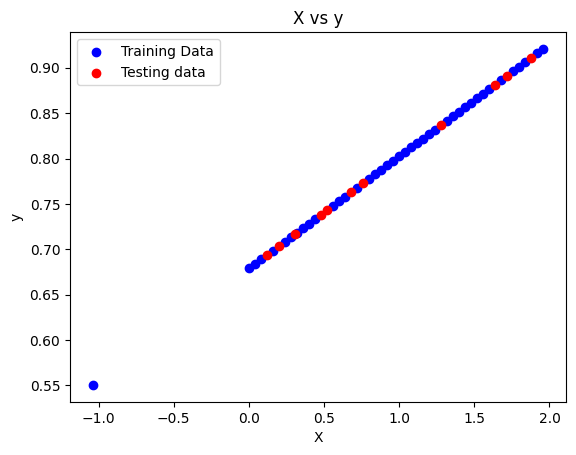

In [38]:
plot_data(X_train_tensors, y_train_tensors, X_test_tensors, y_test_tensors)

In [39]:
from torch import nn


class myFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float32)
        )
        self.bias = nn.Parameter(
            torch.randn(1, requires_grad=True, dtype=torch.float32)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [40]:
# creating our first model


model = myFirstNeuralNetwork()
print(model.state_dict())

OrderedDict({'weights': tensor([-0.3178]), 'bias': tensor([-0.4086])})


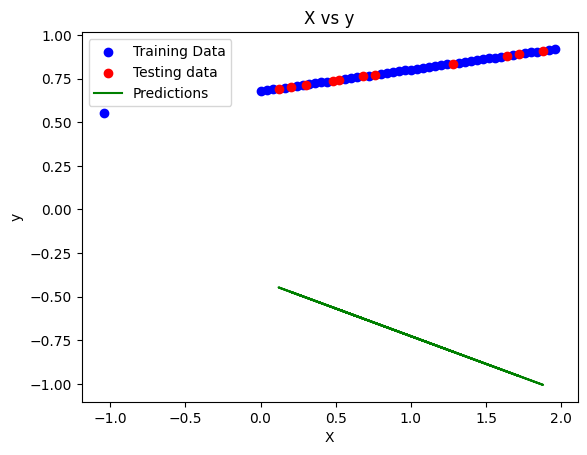

In [41]:
with torch.inference_mode():
    y_preds = model(X_test_tensors)


plot_data(predictions=y_preds)

In [42]:
# set up loss function and optimizer

loss_func = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [43]:
# set up the training loop

epochs = 500
train_loss_list = []
test_loss_list = []

# move everything to device

model.to(device)
X_train_tensors, y_train_tensors = X_train_tensors.to(device), y_train_tensors.to(
    device
)
X_test_tensors, y_test_tensors = X_test_tensors.to(device), y_test_tensors.to(device)

for epoch in range(epochs):
    ### TRAINING MODE
    model.train()

    ### 1. Forward pass

    train_preds = model(X_train_tensors)

    ### 2. Calculate the training loss
    train_loss = loss_func(train_preds, y_train_tensors)

    ### Zero grad the optimizer
    optimizer.zero_grad()

    ### 4. BackPropagration
    train_loss.backward()

    ### 5. Update the optimizer
    optimizer.step()

    ### Testing Mode
    model.eval()

    with torch.inference_mode():
        test_preds = model(X_test_tensors)
        test_loss = loss_func(test_preds, y_test_tensors)

    train_loss_list.append(train_loss.detach().numpy())
    test_loss_list.append(test_loss.detach().numpy())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch: {epoch+1} | Train Loss: {train_loss.item():.4f} | Test Loss: {test_loss.item():.4f}"
        )

Epoch: 50 | Train Loss: 0.0012 | Test Loss: 0.0011
Epoch: 100 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 150 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 200 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 250 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 300 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 350 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 400 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 450 | Train Loss: 0.0000 | Test Loss: 0.0000
Epoch: 500 | Train Loss: 0.0000 | Test Loss: 0.0000


In [44]:
train_loss_list

[array(2.34108206),
 array(0.81795729),
 array(0.30508978),
 array(0.13088644),
 array(0.07032793),
 array(0.04801199),
 array(0.03866364),
 array(0.03380315),
 array(0.03057854),
 array(0.02802422),
 array(0.02580729),
 array(0.02380762),
 array(0.02197696),
 array(0.02029178),
 array(0.0187374),
 array(0.01730262),
 array(0.01597788),
 array(0.01475463),
 array(0.01362505),
 array(0.01258195),
 array(0.01161871),
 array(0.01072922),
 array(0.00990782),
 array(0.00914931),
 array(0.00844887),
 array(0.00780205),
 array(0.00720474),
 array(0.00665317),
 array(0.00614382),
 array(0.00567347),
 array(0.00523912),
 array(0.00483803),
 array(0.00446765),
 array(0.00412562),
 array(0.00380977),
 array(0.00351811),
 array(0.00324877),
 array(0.00300005),
 array(0.00277038),
 array(0.00255829),
 array(0.00236243),
 array(0.00218157),
 array(0.00201456),
 array(0.00186033),
 array(0.00171791),
 array(0.00158639),
 array(0.00146494),
 array(0.00135279),
 array(0.00124922),
 array(0.00115359),
 

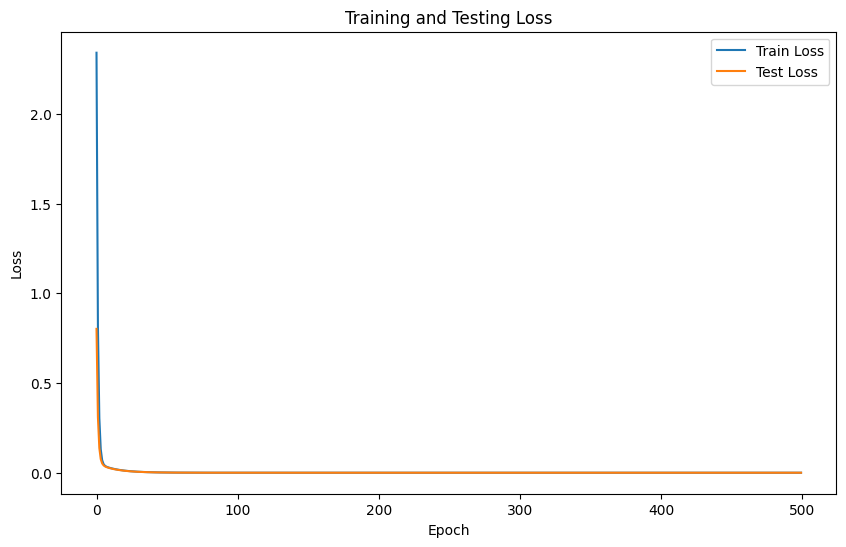

In [45]:
# plot the loss curve

plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_loss_list, label="Train Loss")
plt.plot(range(epochs), test_loss_list, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Testing Loss")
plt.legend()
plt.show()

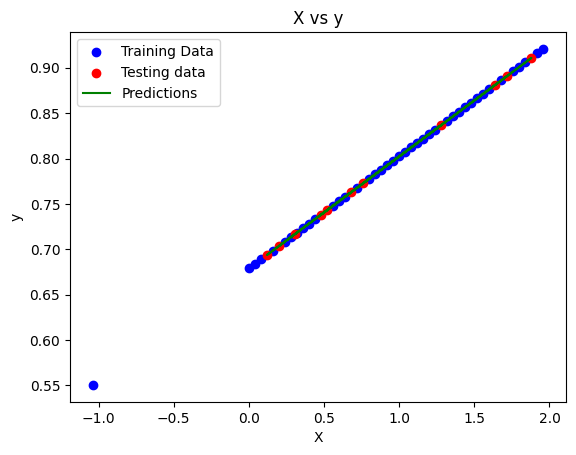

In [46]:
with torch.inference_mode():
    y_preds = model(X_test_tensors)

plot_data(predictions=y_preds)